# Analiza korisnicnkih ocjena u online prodavnici
**Autor** Adi Zebic
**Datum** 19.05.2026
**Dataset** Task02.csv

## Uvod
U ovoj analizi istrazujem korisnicke ocjene proizvoda u online prodavnici.Cilj je otkriti kljucne trendove,koje su ekstremne vrijednosti ocjene,kako se prosjecna ocjena mijenja kroz godine,te kako se kategorije proizvoda medjusobno razlikuju po prosjecnoj ocjeni.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv('task02.csv')
print('Broj redova i kolona:', df.shape)
print('\nNazivi kolona:', df.columns.tolist())
print('\nPrvih 5 redova:')
df.head()

Broj redova i kolona: (3078, 11)

Nazivi kolona: ['product_name', 'category', 'price', 'quantity_in_stock', 'quantity_sold', 'brand', 'rating', 'num_of_ratings', 'date_added', 'color', 'revenue']

Prvih 5 redova:


,product_name,category,price,quantity_in_stock,quantity_sold,brand,rating,num_of_ratings,date_added,color,revenue
0,"iPad mini (2021) (64GB, Blue)",Tablets,499.00,266.0,185.0,Apple,8.75,151.0,2/2/2022,blue,92315.00
1,K55 RGB (Red),Keyboards,49.99,0.0,561.0,Corsair,8.50,455.0,8/14/2022,red,28044.39
2,Fenix 7 (Purple),Watches,699.99,0.0,374.0,Garmin,9.20,305.0,4/20/2022,purple,261796.26
3,"Mate 40 (256GB, Orange)",Smartphones,899.00,182.0,615.0,Huawei,8.50,500.0,10/23/2024,orange,552885.00
4,Rival 600 (Red),Mice,79.99,35.0,698.0,SteelSeries,9.25,556.0,9/29/2020,red,55833.02


In [3]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year'] = df['date_added'].dt.year
print('Nedostajuce vrijednosti:\n',df.isnull().sum())

Nedostajuce vrijednosti:
 product_name           0
category               0
price                  2
quantity_in_stock     44
quantity_sold          1
brand                  0
rating               140
num_of_ratings         9
date_added             0
color                  0
revenue                3
year                   0
dtype: int64


## Analiticki uvid 1 Ekstremne vrijednosti ocjena
Koji proizvod je dobio najvisu,a koji najnizu ocjenu

In [4]:
max_ocjena = df['rating'].max()
min_ocjena = df['rating'].min()
najbolji = df[df['rating'] == max_ocjena][['product_name', 'category', 'rating']].iloc[0]
najgori = df[df['rating'] == min_ocjena][['product_name', 'category', 'rating']].iloc[0]
print("=" * 50)
print(f"Najvisa ocjena: {max_ocjena}")
print(f"Proizvod: {najbolji['product_name']}")
print(f"Kategorija: {najbolji['category']}")
print("=" * 50)
print(f"Najniza ocjena: {min_ocjena}")
print(f"Proizvod: {najgori['product_name']}")
print(f"Kategorija: {najgori['category']}")
print("=" * 50)

Najvisa ocjena: 9.75
Proizvod: Harry Potter Hogwarts Castle (71043) (Brown)
Kategorija: Toys
Najniza ocjena: 5.5
Proizvod: 32X (Green)
Kategorija: Gaming Consoles


## Analiticki uvid 2 Prosjecna ocjena kroz godine
Linijski dijagram pokazuje kako se prosjecna ocjena mijenjala iz godine u godinu.

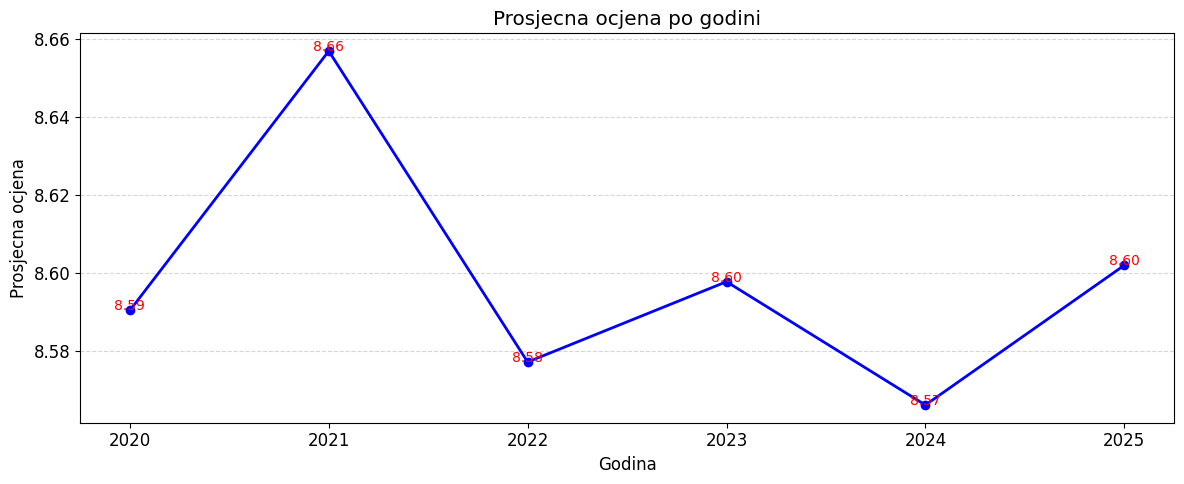

   Godina  Prosjecna Ocjena
0    2020          8.590373
1    2021          8.656977
2    2022          8.577137
3    2023          8.597762
4    2024          8.566098
5    2025          8.601972


In [5]:
godisnji_prosjek = df.groupby('year')['rating'].mean().reset_index()
godisnji_prosjek.columns = ['Godina', 'Prosjecna Ocjena']

plt.figure()
plt.plot(godisnji_prosjek['Godina'], godisnji_prosjek['Prosjecna Ocjena'], marker='o',linewidth=2,color='blue')

for i, row in godisnji_prosjek.iterrows():
    plt.text(row['Godina'], row['Prosjecna Ocjena'], f"{row['Prosjecna Ocjena']:.2f}", ha='center', fontsize=10, color='red')

plt.title('Prosjecna ocjena po godini')
plt.xlabel('Godina')
plt.ylabel('Prosjecna ocjena')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('trend_ocjena_po_godinama.png',dpi = 150)
plt.show()

print(godisnji_prosjek)


## Analiticki uvid 3 Prosjecne ocjene po kategorijama
Stubicni dijagram pokazuje koje kategorije imaju najvise,a koje najnize prosjecne ocjene korisnika.

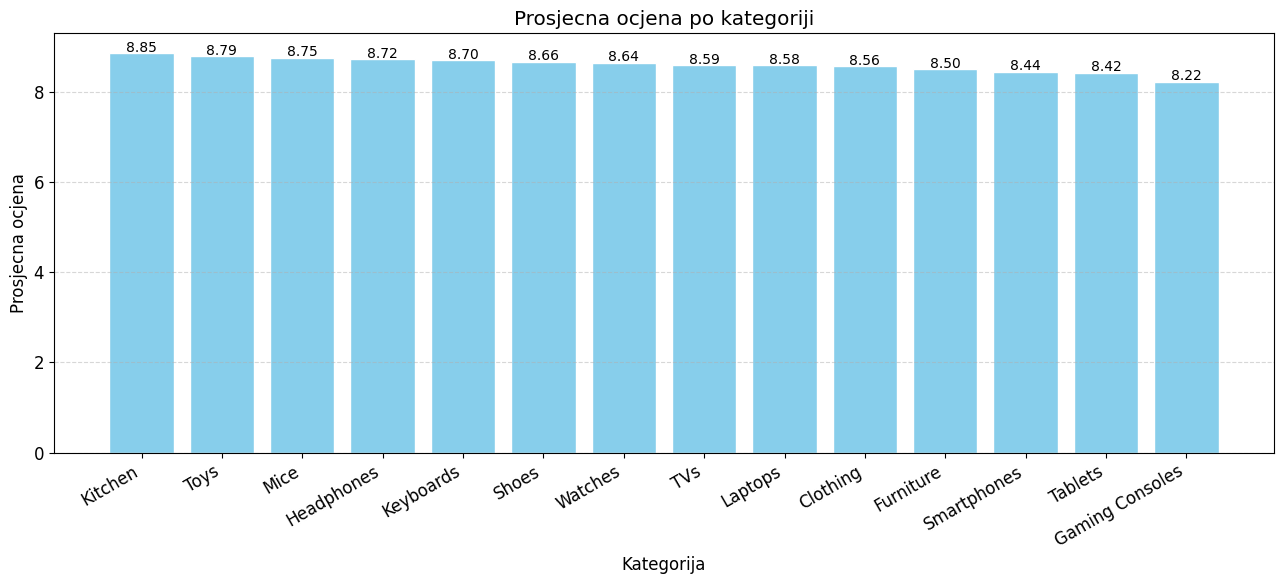

         Kategorija  Prosjecna Ocjena
0           Kitchen          8.847806
1              Toys          8.790253
2              Mice          8.750000
3        Headphones          8.718365
4         Keyboards          8.696075
5             Shoes          8.664725
6           Watches          8.637560
7               TVs          8.587783
8           Laptops          8.584361
9          Clothing          8.562061
10        Furniture          8.497817
11      Smartphones          8.443761
12          Tablets          8.422124
13  Gaming Consoles          8.215803


In [6]:
kategorije = df.groupby('category')['rating'].mean().sort_values(ascending=False).reset_index()
kategorije.columns = ['Kategorija', 'Prosjecna Ocjena']

plt.figure(figsize=(13, 6))
plt.bar(kategorije['Kategorija'], kategorije['Prosjecna Ocjena'], color='skyblue',edgecolor='white')

for i,row in kategorije.iterrows():
    plt.text(i, row['Prosjecna Ocjena'] + 0.03, f"{row['Prosjecna Ocjena']:.2f}", ha='center', fontsize=10)

plt.title('Prosjecna ocjena po kategoriji')
plt.xlabel('Kategorija')
plt.ylabel('Prosjecna ocjena')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('prosjek_ocjena_po_kategorijama.png',dpi = 150)
plt.show()

print(kategorije)

## Zakljucak
**Ekstremne vrijednosti:**
Dataset pokazuje jasan raspon korisnickog zadovoljstva od najlosije do najbolje ocjenjenih proizvoda.
**Trend kroz godine:**
LInijski dijagram oktriva da prosjecna ocjena varira kroz godine,sto moze ukazivati na promjene u kvalitetu.
**Razlike po kategorijama:**
Neke kategorije imaju znatni vise ocjena od drugih,sto nam moze pokazati gdje usmjeriti marketinske napore.
Kategorije s visokim ocjenama treba isticati,a kateogorije s nizim istraziti dublje.

## Refleksija
Najveci izazov je bio pravilo napisati kod i odrediti prave razine grupiranja podataka.
Sljedeci put bih mozda popravio markdown celije da izgledaju preglednije nego sada.